# Quantitative Trading Strategy Backtester

### SMA Crossover Strategy with Parameter Optimization and Walk-Forward Testing

**Author:** Krishna Gupta

This project implements a quantitative trading framework based on Simple Moving Average (SMA) crossover strategies. The framework includes transaction costs, performance evaluation metrics, parameter optimization using grid search, and walk-forward testing to assess out-of-sample robustness.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

## 1. Data Collection and Preparation

This section loads historical stock price data and prepares it for analysis.

### Objectives

- Load historical stock data
- Store data in Dicctionary format with tickers as key and data as value
- Changing data type of column "Date" and setting it as index
- Checking "start" and "end" date of data
- Checking null values 

In [2]:
tickers = [
    "INFY",
    "TCS",
    "HDFCBANK",
    "SBI",
    "DRREDDY",
    "SUNPHARMA",
    "HUL",
    "NESTLE",
    "RPOWER",
    "ONGC"
]
stocks={}
for ticker in tickers:
    df=pd.read_csv(f"data/{ticker}.csv")
    df['Date']=pd.to_datetime(df['Date'])
    df.set_index('Date',inplace=True)
    df.sort_index(inplace=True)
    stocks[ticker]=df

In [3]:
for stock in stocks:
    print(f'Start Date [{stock}]=',stocks[stock].index.min(),end=' ; ')
    print(f'End Date [{stock}]=',stocks[stock].index.max())
    

Start Date [INFY]= 2015-01-01 15:30:00 ; End Date [INFY]= 2024-01-01 15:30:00
Start Date [TCS]= 2015-01-01 15:30:00 ; End Date [TCS]= 2024-01-01 15:30:00
Start Date [HDFCBANK]= 2015-01-01 15:30:00 ; End Date [HDFCBANK]= 2024-01-01 15:30:00
Start Date [SBI]= 2015-01-01 15:30:00 ; End Date [SBI]= 2024-01-01 15:30:00
Start Date [DRREDDY]= 2015-01-01 15:30:00 ; End Date [DRREDDY]= 2024-01-01 15:30:00
Start Date [SUNPHARMA]= 2015-01-01 15:30:00 ; End Date [SUNPHARMA]= 2024-01-01 15:30:00
Start Date [HUL]= 2015-01-01 15:30:00 ; End Date [HUL]= 2024-01-01 15:30:00
Start Date [NESTLE]= 2015-01-01 15:30:00 ; End Date [NESTLE]= 2024-01-01 15:30:00
Start Date [RPOWER]= 2015-01-01 15:30:00 ; End Date [RPOWER]= 2024-01-01 15:30:00
Start Date [ONGC]= 2015-01-01 15:30:00 ; End Date [ONGC]= 2024-01-01 15:30:00


In [4]:
for stock in stocks:
    print(f"Total null values in {stock}=",stocks[stock].isnull().sum().sum())

Total null values in INFY= 0
Total null values in TCS= 0
Total null values in HDFCBANK= 0
Total null values in SBI= 0
Total null values in DRREDDY= 0
Total null values in SUNPHARMA= 0
Total null values in HUL= 0
Total null values in NESTLE= 0
Total null values in RPOWER= 0
Total null values in ONGC= 0


## 2. SMA Crossover Signal Generation and Visualization

The baseline trading strategy used throughout this project is the 50-Day / 200-Day Simple Moving Average (SMA) Crossover Strategy. And infosys stock is used for the visualisation.

For each stock, two moving averages are calculated:

- 50-Day SMA (Short-Term Trend)
- 200-Day SMA (Long-Term Trend)

A trading signal is generated based on the relative position of these moving averages.

### Signal Rules

**Buy Signal**
- Generated when the 50-Day SMA crosses above the 200-Day SMA.

**Sell Signal**
- Generated when the 50-Day SMA crosses below the 200-Day SMA.

The crossover points are identified using changes in the signal state and are stored separately for later use in backtesting.

### Visualization

To verify that signals are generated correctly, the closing price, moving averages, and crossover events are plotted.

The chart includes:

- Closing Price
- 50-Day SMA
- 200-Day SMA
- Buy Signal Markers
- Sell Signal Markers

This visualization serves as a validation step before implementing the backtesting engine.

In [5]:
for stock in stocks:
    stocks[stock]['MA50']=stocks[stock]['Close'].rolling(50).mean()
    stocks[stock]['MA200']=stocks[stock]['Close'].rolling(200).mean()
    stocks[stock]['Signal']=(stocks[stock]['MA50']>stocks[stock]['MA200'])*1
    stocks[stock]['Crossover']=stocks[stock]['Signal']-stocks[stock]['Signal'].shift(1)


In [6]:
BUY_signal_date={}
SELL_signal_date={}
for stock in stocks:
    BUY_signal_date.update({stock:stocks[stock][stocks[stock]['Crossover']>0].index})
    SELL_signal_date.update({stock:stocks[stock][stocks[stock]['Crossover']<0].index})

trace1=go.Scatter(x=stocks['INFY'].index,y=stocks['INFY']['Close'],mode="lines",name='Close_Price',line={'color':'blue'})
trace2=go.Scatter(x=stocks['INFY'].index,y=stocks['INFY']['MA50'],mode="lines",name='MA50',line={'color':'orange'})
trace3=go.Scatter(x=stocks['INFY'].index,y=stocks['INFY']['MA200'],mode="lines",name='MA200',line={'color':'red'})
trace4=go.Scatter(x=BUY_signal_date['INFY'],y=stocks['INFY']['Close'][stocks['INFY']['Crossover']>0],mode="markers",name='BUY-signal',marker = {'symbol':'triangle-up', 'color':'green', 'size':15})
trace5=go.Scatter(x=SELL_signal_date['INFY'],y=stocks['INFY']['Close'][stocks['INFY']['Crossover']<0],mode="markers",name='SELL-signal',marker = {'symbol':'triangle-down', 'color':'red', 'size':15})

data=[trace1,trace2,trace3,trace4,trace5]
layout=go.Layout(title='INFY Crossover',xaxis={'title':'Date'},yaxis={'title':'Price'})
fig=go.Figure(data,layout)
fig.show()

sharpe ratio ko change krna mt bhoolna, risk free return daal dena

## 3. Backtesting Engine Implementation

After generating trading signals, a backtesting engine is implemented to simulate how the SMA crossover strategy would have performed on historical market data.

The engine follows a **long-only trading approach**, where the portfolio is either fully invested in the stock or entirely in cash.

### Trading Logic

When a buy signal is generated:

* Available capital is used to purchase shares.
* Transaction costs are deducted before entering the position.
* The portfolio becomes fully invested.

When a sell signal is generated:

* All held shares are liquidated.
* Transaction costs are applied to the sale proceeds.
* The portfolio returns to a cash position.

This process is repeated throughout the entire historical period to simulate realistic trading activity.

### Portfolio Tracking

The backtester continuously tracks portfolio value through time by recording:

* Cash balance
* Number of shares held
* Daily portfolio value
* Equity curve evolution

The resulting equity curve represents the growth of the trading account over the testing period.

### Performance Evaluation

Several performance metrics are calculated to evaluate the effectiveness of the strategy:

* **Strategy Return (%)** – Total percentage gain or loss generated by the strategy.
* **Number of Trades** – Total completed buy-sell trading cycles.
* **Sharpe Ratio** – Risk-adjusted performance measure based on daily returns.
* **Maximum Drawdown** – Largest peak-to-trough decline experienced by the portfolio.

### Transaction Cost Modeling

To improve realism, a transaction cost of **0.1% per trade** is incorporated into both buy and sell transactions. This prevents performance estimates from being overly optimistic and better reflects real market conditions.


In [19]:
def run_backtest_on_DF(stock_DF,initial_capital=100000,fast=50,slow=200,transaction_cost=0.001):
    """
Run an SMA crossover backtest on a price DataFrame.

Parameters
----------
stock_DF : pandas.DataFrame
    Historical OHLCV data containing at least a 'Close' column.

initial_capital : float, default=100000
    Starting portfolio value.

fast : int, default=50
    Fast moving average window.

slow : int, default=200
    Slow moving average window.

transaction_cost : float, default=0.001
    Transaction cost applied on each buy and sell trade.

Returns
-------
dict
    Dictionary containing:

    - strategy_return : total percentage return
    - equity_strat : equity curve series
    - num_trades : completed trades
    - sharpe_ratio : annualized Sharpe ratio
    - max_drawdown : maximum drawdown
"""
    df=stock_DF.copy()

    df[f'MA{fast}']=df['Close'].rolling(fast).mean()
    df[f'MA{slow}']=df['Close'].rolling(slow).mean()
    df['Signal']=(df[f'MA{fast}']>df[f'MA{slow}'])*1
    df['Crossover']=df['Signal']-df['Signal'].shift(1)
    
    capital=initial_capital
    shares=0 
    invested=False
    portfolio_value=[]

    for day in df.index:
        if df.loc[day,'Signal']==1 and invested==False:
            cost_b=transaction_cost*capital
            shares=(capital-cost_b)/df.loc[day,'Close']
            capital=0
            invested=True
            
        elif df.loc[day,'Signal']==0 and invested==True:
            capital=shares*df.loc[day,'Close']*(1-transaction_cost)
            shares=0
            invested=False
        

        if invested:
            portfolio_value.append(shares*df.loc[day,'Close'])
        
        else:
            portfolio_value.append(capital)

    equity_series= pd.Series(
    data=portfolio_value,
    index=df.index)

    daily_returns=equity_series.pct_change().dropna()
    active_returns=daily_returns[(df['Signal']==1)[1:]]
    s_ratio=(active_returns.mean()*252-0.07)/(active_returns.std()*(252)**0.5)

    cum_max=equity_series.cummax()
    Drawdown=(equity_series-cum_max)/cum_max
    maximum_drawdown=Drawdown.min()

    return {'strategy_return':(equity_series.iloc[-1]-equity_series.iloc[0])*100/equity_series.iloc[0],
            'equity_strat':equity_series,
            'num_trades':len(df['Crossover'][df['Crossover']!=0])//2,
            'sharpe_ratio':s_ratio,
            'max_drawdown':maximum_drawdown

            }
    
    
def run_backtest(stock,initial_capital=100000,fast=50,slow=200,transaction_cost=0.001):
    df=stocks[stock].copy()
    return run_backtest_on_DF(df,initial_capital,fast,slow,transaction_cost)

## 4. Buy-and-Hold Benchmark Strategy and comparison with SMA strategy

To evaluate whether active trading adds value, a Buy-and-Hold benchmark strategy is implemented alongside the SMA crossover strategy.

In a Buy-and-Hold approach, the entire portfolio is invested in the stock at the beginning of the investment period and held without any further trading activity. No buy or sell decisions are made after the initial purchase.

By comparing the SMA crossover strategy against Buy-and-Hold, we can determine:

- Whether active trading improves returns.
- Whether risk-adjusted performance improves.
- Whether trend-following signals add value over passive investing.


### Benchmark Logic

1. Invest the full initial capital on the first trading day.
2. Purchase as many shares as possible at the initial closing price.
3. Hold the position throughout the entire investment horizon.
4. Track the portfolio value using daily closing prices.

### output

The Buy-and-Hold benchmark generates:

- Total Return (%)
- Equity Curve


In [8]:
def Buy_Hold_on_DF(stock,initial_capital=100000):
    """
Run a Buy-and-Hold benchmark strategy.

Parameters
----------
stock : pandas.DataFrame
    Historical price data containing a 'Close' column.

initial_capital : float, default=100000
    Initial portfolio value.

Returns
-------
dict
    Dictionary containing:

    - Buy_Hold_return : percentage return
    - equity_Buy_Hold : buy-and-hold equity curve
"""
    data=stock.copy()
    capital=initial_capital
    shares=capital/data['Close'].iloc[0]
    buy_hold=[]
    for day in data.index:
        portfolio_value=shares*data.loc[day,'Close']
        buy_hold.append(portfolio_value)

    Buy_Hold=pd.Series(
    data=buy_hold,
    index=data.index
    )
    
    return {'Buy_Hold_return':(Buy_Hold.iloc[-1]-Buy_Hold.iloc[0])*100/Buy_Hold.iloc[0],
            'equity_Buy_Hold':Buy_Hold
            }


def Buy_Hold(stock,initial_capital=100000):
    data=stocks[stock].copy()
    return Buy_Hold_on_DF(data,initial_capital=initial_capital)


### Equity Curve Analysis

An equity curve tracks the evolution of portfolio value through time and provides a visual representation of strategy performance.

The figure below compares:

- SMA Crossover Portfolio Value
- Buy-and-Hold Portfolio Value

This comparison highlights the impact of active trend-following decisions relative to passive long-term investing.

In [9]:

trace1=go.Scatter(x=run_backtest('INFY',100000)['equity_strat'].index,y=run_backtest('INFY',100000)['equity_strat'],mode='lines',name='Crossover_strat',line={'color':'blue'})
trace2=go.Scatter(x=Buy_Hold('INFY',100000)['equity_Buy_Hold'].index,y=Buy_Hold('INFY',100000)['equity_Buy_Hold'],mode='lines',name='buy&hold',line={'color':'green'})
data=[trace1,trace2]
layout=go.Layout(title='INFY — Strategy vs Buy & Hold',xaxis={'title':'Date'},yaxis={'title':'Portfolio Value (INR)'})
fig=go.Figure(data,layout)
fig.show()

### Multi-Stock Performance Evaluation

The default 50/200 SMA crossover strategy is evaluated across multiple Indian stocks and compared against the Buy-and-Hold benchmark.

The summary table reports:

- Strategy Return (%)
- Buy-and-Hold Return (%)
- Number of complete Trades
- Sharpe Ratio
- Maximum Drawdown

This serves as the baseline performance assessment before parameter optimization and walk-forward testing.

In [10]:
def generate_summary(stocks_dictionary,initial_capital=100000):
    """
Generate performance summary for all stocks.

Parameters
----------
stocks_dictionary : dict
    Dictionary containing stock DataFrames.

initial_capital : float, default=100000

Returns
-------
pandas.DataFrame
    Summary table containing:

    - strategy return
    - buy-and-hold return
    - number of trades
    - Sharpe ratio
    - maximum drawdown
       """
    result=[]
    for stock in stocks_dictionary:
        sma=run_backtest(stock,initial_capital)
        bh=Buy_Hold(stock,initial_capital)
        result.append({
            'stock':stock,
            'Strategy Return (%)':sma['strategy_return'],
            'Buy_Hold Return (%)':bh['Buy_Hold_return'],
            'Completed Trades':sma['num_trades'],
            'Sharpe_Ratio':sma['sharpe_ratio'],
            'Max_Drawdown(magnitude)':-1*sma['max_drawdown']
            })
    return pd.DataFrame(result)

In [11]:
generate_summary(stocks,initial_capital=100000)

,stock,Strategy Return (%),Buy_Hold Return (%),Completed Trades,Sharpe_Ratio,Max_Drawdown(magnitude)
0,INFY,40.011968,214.292950,6,0.154438,0.436701
1,TCS,119.266971,199.431166,8,0.507306,0.266795
2,HDFCBANK,73.357793,256.728709,7,0.300776,0.338868
3,SBI,26.970439,104.251592,7,0.030890,0.551906
4,DRREDDY,32.997936,81.331568,7,0.148971,0.399341
5,SUNPHARMA,34.719277,53.277791,6,0.142643,0.475883
6,HUL,63.921887,250.023073,7,0.197015,0.258452
7,NESTLE,172.539229,333.244698,6,0.506179,0.228800
8,RPOWER,48.431973,-61.618590,7,0.358366,0.719849
9,ONGC,90.685476,-10.472163,5,0.395915,0.396161


## 5. Parameter Optimization using Grid Search

The default 50/200 SMA strategy may not be the most effective parameter combination for every stock. To explore alternative configurations, a grid search optimization framework is implemented.

Grid search systematically evaluates multiple combinations of fast and slow moving-average windows and records the resulting strategy performance.

### Search Space

- Fast SMA Windows:[10, 20, 30, 50]
- Slow SMA Windows:[100, 150, 200]
- Only valid combinations where Fast SMA < Slow SMA are evaluated.

### Optimization Objective

Each parameter combination is backtested and ranked using the **Sharpe Ratio**, which measures risk-adjusted performance.

For every combination, the following metrics are recorded:

- Fast SMA Window
- Slow SMA Window
- Sharpe Ratio
- Strategy Return (%)
- Maximum Drawdown

The best-performing parameter combination is selected based on the highest Sharpe Ratio.

In [12]:
def grid_search_on_DF(stock_DF,initial_capital=100000,fast_windows=[10, 20, 30, 50],slow_windows=[100, 150, 200]):
    """
Perform parameter optimization using grid search.

Parameters
----------
stock_DF : pandas.DataFrame
    Historical price data.

initial_capital : float, default=100000

fast_windows : list
    Candidate fast moving-average windows.

slow_windows : list
    Candidate slow moving-average windows.

Returns
-------
pandas.DataFrame
    Ranked parameter combinations sorted by Sharpe ratio.
"""
    results=[]
    for fast in fast_windows:
        for slow in slow_windows:
            if fast<slow:
               output=run_backtest_on_DF(stock_DF,fast=fast,slow=slow,initial_capital=initial_capital)
               results.append({
                   'fast':fast,
                   'slow':slow,
                   'sharpe_ratio':output['sharpe_ratio'],
                   'Max_Drawdown(magnitude)':-1*output['max_drawdown'],
                   'strategy_return': output['strategy_return']
               })
            else:
                pass
    df=pd.DataFrame(results).sort_values('sharpe_ratio',ascending=False).reset_index(drop=True)
    return df

def grid_search(stock,initial_capital=100000,fast_windows=[10, 20, 30, 50],slow_windows=[100, 150, 200]):
    stock_DF=stocks[stock].copy()
    return grid_search_on_DF(stock_DF,initial_capital,fast_windows,slow_windows)





### fast and slow window combination Analysis using a Heatmap
The optimization results are visualized using a Sharpe Ratio heatmap.

Each cell represents the Sharpe Ratio obtained from a specific Fast SMA and Slow SMA combination. Brighter regions indicate stronger risk-adjusted performance, while darker regions indicate weaker parameter choices.

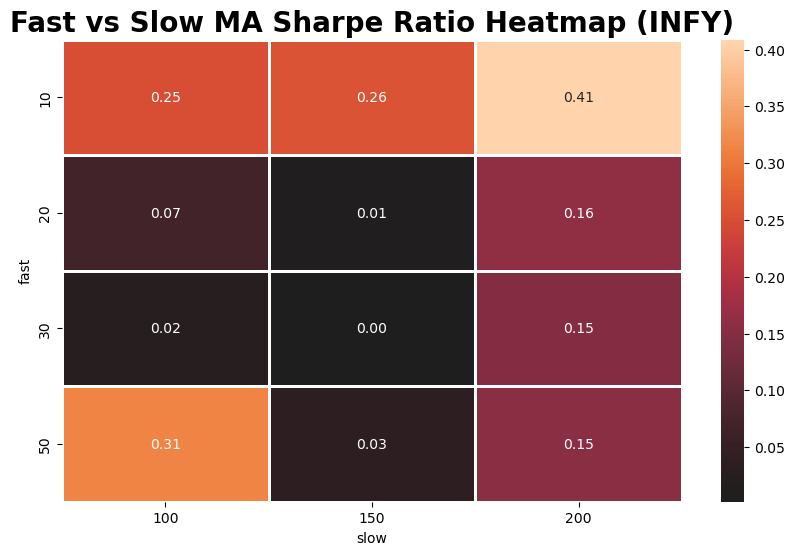

In [13]:
result=grid_search('INFY')
heatmap_data=result.pivot(
    index='fast',
    columns='slow',
    values='sharpe_ratio'
)
plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    center=0,
    linecolor='white',
    linewidths=1
)
plt.title("Fast vs Slow MA Sharpe Ratio Heatmap (INFY)",fontsize=20,fontweight='bold')
plt.show()

### Optimized Parameter Comparison

After identifying the optimal SMA parameter combination for each stock, the strategy is re-evaluated using the best-performing Fast and Slow moving-average windows obtained from the grid search process.

The optimized strategy is then compared against the default 50/200 SMA benchmark.

#### Comparison Metrics

For each stock, the following information is reported:

- Default Sharpe Ratio (50/200)
- Optimized Sharpe Ratio
- Best Fast SMA Window
- Best Slow SMA Window
- Default Strategy Return (%)
- Optimized Strategy Return (%)
- Sharpe Ratio Improvement

#### Objective

The purpose of this comparison is to quantify the impact of parameter optimization and determine whether stock-specific SMA configurations provide superior risk-adjusted performance relative to the default 50/200 strategy.

In [14]:
def generate_optimized_summary(stocks,initial_capital=100000):
    result=[]
    best_comb={}
    for stock in stocks:
        best_comb.update(
            {stock:grid_search(stock).iloc[0]}
    )
    for stock in stocks:
        default=run_backtest(stock,fast=50,slow=200)
        best=best_comb[stock]
        optimized=run_backtest(stock,fast=int(best_comb[stock]['fast']),slow=int(best_comb[stock]['slow']),initial_capital=initial_capital)
        result.append({
            'stock':stock,
            'Default Sharpe(50/200)': default['sharpe_ratio'],
            'Optimized Sharpe': optimized['sharpe_ratio'],
            'Best Fast': best['fast'],
            'Best Slow': best['slow'],
            'Default Return (%)': default['strategy_return'],
            'Optimized Return (%)': optimized['strategy_return']
        })
    df=pd.DataFrame(result)
    df['sharpe_improvemnt']=df['Optimized Sharpe']-df['Default Sharpe(50/200)']
    return df


    

Performance Comparison: Default vs Optimized SMA Parameters

In [15]:
generate_optimized_summary(stocks)

,stock,Default Sharpe(50/200),Optimized Sharpe,Best Fast,Best Slow,Default Return (%),Optimized Return (%),sharpe_improvemnt
0,INFY,0.154438,0.408665,10.0,200.0,40.011968,77.251354,0.254227
1,TCS,0.507306,0.507306,50.0,200.0,119.266971,119.266971,0.000000
2,HDFCBANK,0.300776,0.384560,30.0,200.0,73.357793,100.274961,0.083784
3,SBI,0.030890,0.526611,50.0,100.0,26.970439,129.042986,0.495722
4,DRREDDY,0.148971,0.265543,50.0,150.0,32.997936,48.462512,0.116572
5,SUNPHARMA,0.142643,0.247751,10.0,150.0,34.719277,35.353956,0.105107
6,HUL,0.197015,0.314852,20.0,200.0,63.921887,94.033389,0.117837
7,NESTLE,0.506179,0.643396,30.0,200.0,172.539229,225.360946,0.137217
8,RPOWER,0.358366,0.683876,10.0,100.0,48.431973,175.584416,0.325509
9,ONGC,0.395915,0.664698,20.0,100.0,90.685476,146.384304,0.268783


## 6. Walk-Forward Optimization

The parameter combinations identified through grid search were obtained using the entire historical dataset. While this often produces strong in-sample results, it may lead to overfitting, where parameters perform well on historical data but fail to generalize to unseen market conditions.

To obtain a more realistic estimate of future performance, a walk-forward optimization framework is implemented.

### Methodology

The historical dataset is divided into two non-overlapping periods:

#### Training Period
- 2015 – 2019

#### Testing Period
- 2020 – 2024

For each stock:

1. Grid search optimization is performed only on the training period.
2. The parameter combination with the highest Sharpe Ratio is selected.
3. The selected parameters are applied to the unseen testing period.
4. Performance metrics are calculated using only out-of-sample data.

This procedure mimics a real-world scenario where future data is unavailable during parameter selection.

In [16]:
def walk_forward(stock):
    """
Perform walk-forward optimization.

Training Period
---------------
2015-2019

Testing Period
--------------
2020-2024

Procedure
---------
1. Optimize SMA parameters on training data.
2. Select best parameter combination using Sharpe ratio.
3. Evaluate selected parameters on unseen test data.

Returns
-------
dict
    Dictionary containing:

    - stock
    - fast
    - slow
    - sharpe_ratio
    - strategy_return
    - num_trades
    - Max_Drawdown
"""
    train=stocks[stock].loc[:'2019-12-31'].copy()
    test=stocks[stock].loc['2020-01-01':].copy()
    best=grid_search_on_DF(train).iloc[0]
    result=run_backtest_on_DF(test,fast=int(best['fast']),slow=int(best['slow']))
    return {
    'stock': stock,
    'fast': int(best['fast']),
    'slow': int(best['slow']),
    'sharpe_ratio':float(result['sharpe_ratio']),
    'Max_Drawdown':float(result['max_drawdown']),
    'strategy_return': float(result['strategy_return']),
    'num_trades': int(result['num_trades'])
}

### Walk-Forward Performance Summary

The table below compares the out-of-sample performance of the optimized strategy against the default 50/200 SMA benchmark.

For each stock, the following information is reported:

- Best Fast SMA
- Best Slow SMA
- Walk-Forward Sharpe Ratio
- Default Sharpe Ratio (50/200)
- Sharpe Ratio Improvement

This comparison evaluates whether parameter optimization discovered on historical training data remains effective when applied to previously unseen market data.

In [17]:
wf_result=[]
for stock in stocks:
    result_default=run_backtest_on_DF(stocks[stock].loc['2020-01-01':].copy(),fast=50,slow=200)
    result_optimized=walk_forward(stock)
    wf_result.append({
        'stock':result_optimized['stock'],
        'best_fast':result_optimized['fast'],
        'best_slow':result_optimized['slow'],
        'WF_sharpe_ratio':result_optimized['sharpe_ratio'],
        'default_sharpe(50/200)':result_default['sharpe_ratio']
        })
wf_df=pd.DataFrame(wf_result)
wf_df['improvement']=wf_df['WF_sharpe_ratio']-wf_df['default_sharpe(50/200)']
wf_df

,stock,best_fast,best_slow,WF_sharpe_ratio,default_sharpe(50/200),improvement
0,INFY,50,200,0.431569,0.431569,0.000000
1,TCS,50,200,0.372103,0.372103,0.000000
2,HDFCBANK,10,100,0.057984,0.455883,-0.397899
3,SBI,50,100,1.107154,0.804006,0.303148
4,DRREDDY,50,100,0.127799,-0.144542,0.272341
5,SUNPHARMA,20,150,0.672813,1.006860,-0.334047
6,HUL,20,200,-0.445348,-0.523858,0.078510
7,NESTLE,30,200,0.430699,0.114280,0.316418
8,RPOWER,50,200,1.180970,1.180970,0.000000
9,ONGC,20,100,0.926450,0.936275,-0.009824


### Out-of-Sample Equity Curve Comparison

To visualize the effectiveness of walk-forward optimization, the optimized SMA strategy is compared against:

- Default SMA Strategy (50/200)
- Buy-and-Hold Benchmark

The comparison is performed exclusively on the testing period (2020–2024).

The resulting equity curves provide a visual representation of portfolio growth under different approaches and highlight the impact of parameter optimization on unseen data.

In [18]:
stock_to_plot='SBI'
test=stocks[stock_to_plot].loc['2020-01-01':].copy()
wf=walk_forward(stock_to_plot)
default_result=run_backtest_on_DF(
    test,
    fast=50,
    slow=200
)
optimized_result=run_backtest_on_DF(
    test,
    fast=wf['fast'],
    slow=wf['slow']
)
buy_hold=Buy_Hold_on_DF(
    test
)
trace_1=go.Scatter(x=default_result['equity_strat'].index,y=default_result['equity_strat'],mode='lines',name='Default (50/200)')
trace_2=go.Scatter(x=optimized_result['equity_strat'].index,y=optimized_result['equity_strat'],mode='lines',name=f"Optimized ({wf['fast']}/{wf['slow']})")
trace_3=go.Scatter(x=buy_hold['equity_Buy_Hold'].index,y=buy_hold['equity_Buy_Hold'],mode='lines',name='Buy_Hold')
data=[trace_1,trace_2,trace_3]
layout=go.Layout(title={'text': f'Equity Growth: Buy & Hold vs SMA Strategies<br><sup>Test Period: 2020-2024</sup><br><sup>stock={stock_to_plot}</sup>','x': 0.5},xaxis={'title':'Date'},yaxis={'title':'Portfolio Value (INR)'})
fig=go.Figure(data,layout)
fig.show()


## 7. Conclusions

### Key Findings

- The 50/200 SMA crossover strategy produced profitable results across several stocks but was not consistently superior to Buy-and-Hold.
- Optimal SMA parameters varied considerably across stocks, indicating that strategy performance is highly parameter-dependent.
- While grid search improved in-sample performance, walk-forward testing showed that these gains did not always generalize to unseen data.
- The results highlight both the benefits and limitations of parameter optimization and emphasize the importance of out-of-sample validation when developing quantitative trading strategies.
